# LHC Trigger — Reinforcement Learning Agent

Models real-time particle event selection at the LHC as a **Markov Decision Process**.

## Reward Function

$$r(s, a) = \begin{cases} +R_{\text{sig}} & \text{if } a=\text{accept},\ \text{is\_signal} \\ -R_{\text{miss}} & \text{if } a=\text{reject},\ \text{is\_signal} \\ -R_{\text{bkg}} & \text{if } a=\text{accept},\ \neg\text{is\_signal} \\ -R_{\text{over}} & \text{if } a=\text{accept and over budget} \\ 0 & \text{if } a=\text{reject},\ \neg\text{is\_signal} \end{cases}$$

**Objectives encoded:**
1. `+R_sig` — reward true positives: maximise signal efficiency  
2. `−R_miss` — penalise false negatives: signal events are scientifically irreplaceable  
3. `−R_bkg` — penalise false positives: background wastes finite storage  
4. `−R_over` — hard budget enforcement: extra penalty for accepting beyond capacity  

The agent observes `(score_bin, budget_remaining_bin)`, so it can condition its policy on remaining storage — something no static threshold can do.

## 1 — Configuration

In [1]:
# ── Simulation parameters ────────────────────────────────────────────────────
EVENTS_PER_EPISODE = 1000     # collisions per episode
SIGNAL_RATE        = 0.001    # P(signal) = 1 in 1000
STORAGE_BUDGET     = 100      # max accepts per episode

# ── Reward function coefficients ─────────────────────────────────────────────
# R(s, a):
#   Accept signal      → +R_SIG         reward true positive
#   Miss signal        → -R_MISS        penalise false negative (irreplaceable!)
#   Accept background  → -R_BKG         penalise wasting storage
#   Reject background  →  0             correct, costs nothing
#   Over budget        → -R_OVERBUDGET  extra penalty for exceeding storage limit
R_SIG        = 10.0
R_MISS       = 15.0   # missing signal is worse than a false positive
R_BKG        =  1.0
R_OVERBUDGET =  5.0

# ── State discretisation ─────────────────────────────────────────────────────
N_SCORE_BINS  = 10
N_BUDGET_BINS = 10

# ── Q-learning hyperparameters ───────────────────────────────────────────────
ALPHA     = 0.1    # learning rate
GAMMA     = 0.99   # discount factor
EPS_START = 1.0    # initial exploration
EPS_END   = 0.05   # minimum exploration
EPS_DECAY = 0.995  # per-episode multiplicative decay
N_EPISODES = 2000

print("Configuration loaded.")

Configuration loaded.


## 2 — Environment (MDP)

In [2]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces


class LHCTriggerEnv(gym.Env):
    """
    LHC trigger modelled as a discrete MDP.

    State  : (signal_score_bin, budget_remaining_bin)  — both integers
    Action : 0 = REJECT,  1 = ACCEPT

    Each step corresponds to one collision event.
    The agent observes a discretised signal score and how much storage
    capacity remains, allowing budget-aware decisions.
    """

    def __init__(self):
        super().__init__()
        self.observation_space = spaces.MultiDiscrete([N_SCORE_BINS, N_BUDGET_BINS])
        self.action_space      = spaces.Discrete(2)

    # ── helpers ───────────────────────────────────────────────────────────────
    def _new_event(self):
        """Sample one collision event; return (composite_score, is_signal)."""
        is_signal = self.np_random.random() < SIGNAL_RATE
        if is_signal:
            features = self.np_random.normal([0.75, 0.70, 0.80, 0.72], 0.12, size=4)
        else:
            features = self.np_random.normal([0.35, 0.40, 0.30, 0.38], 0.18, size=4)
        score = float(np.clip(np.dot([0.35, 0.25, 0.25, 0.15], features), 0, 1))
        return score, is_signal

    def _obs(self):
        score_bin  = min(int(self._score        * N_SCORE_BINS),  N_SCORE_BINS  - 1)
        budget_bin = min(int(self._budget_frac  * N_BUDGET_BINS), N_BUDGET_BINS - 1)
        return np.array([score_bin, budget_bin], dtype=np.int64)

    # ── Gymnasium API ─────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._step       = 0
        self._accepted   = 0
        self._sig_total  = 0
        self._sig_caught = 0

        self._score, self._is_signal = self._new_event()
        self._sig_total  += self._is_signal
        self._budget_frac = 1.0
        return self._obs(), {}

    def step(self, action):
        over_budget = self._accepted >= STORAGE_BUDGET

        # ── Reward function ───────────────────────────────────────────────────
        if action == 1:        # ACCEPT
            reward = R_SIG if self._is_signal else -R_BKG
            if over_budget:
                reward -= R_OVERBUDGET
            else:
                self._accepted += 1
        else:                  # REJECT
            reward = -R_MISS if self._is_signal else 0.0

        if action == 1 and self._is_signal:
            self._sig_caught += 1

        self._step    += 1
        terminated     = self._step >= EVENTS_PER_EPISODE

        self._score, self._is_signal = self._new_event()
        self._sig_total  += self._is_signal
        self._budget_frac = max(0.0, (STORAGE_BUDGET - self._accepted) / STORAGE_BUDGET)

        info = {}
        if terminated:
            info = {
                "signal_efficiency": self._sig_caught / max(1, self._sig_total),
                "bkg_accepted":      self._accepted - self._sig_caught,
                "total_accepted":    self._accepted,
            }
        return self._obs(), reward, terminated, False, info


# Quick sanity check
env = LHCTriggerEnv()
obs, _ = env.reset(seed=0)
print(f"Observation space : {env.observation_space}")
print(f"Action space      : {env.action_space}")
print(f"Sample observation: {obs}")

Observation space : MultiDiscrete([10 10])
Action space      : Discrete(2)
Sample observation: [3 9]


## 3 — Agent (Tabular Q-learning)

In [3]:
class QLearningAgent:
    """
    Tabular Q-learning with ε-greedy exploration.

    Update rule (Bellman):
        Q(s,a) ← Q(s,a) + α · [r + γ · max_a' Q(s',a') − Q(s,a)]

    State is (score_bin, budget_bin), so the Q-table has shape
    (N_SCORE_BINS, N_BUDGET_BINS, 2) — fully tabular, no function
    approximation needed given the small discrete state space.
    """

    def __init__(self):
        self.Q       = np.zeros((N_SCORE_BINS, N_BUDGET_BINS, 2))
        self.epsilon = EPS_START

    def get_action(self, obs, greedy=False):
        if not greedy and np.random.random() < self.epsilon:
            return np.random.randint(2)                        # explore
        return int(np.argmax(self.Q[obs[0], obs[1]]))         # exploit

    def update(self, obs, action, reward, next_obs, done):
        current = self.Q[obs[0], obs[1], action]
        target  = reward if done else reward + GAMMA * np.max(self.Q[next_obs[0], next_obs[1]])
        self.Q[obs[0], obs[1], action] += ALPHA * (target - current)

    def decay_epsilon(self):
        self.epsilon = max(EPS_END, self.epsilon * EPS_DECAY)


agent = QLearningAgent()
print(f"Q-table shape: {agent.Q.shape}  ({N_SCORE_BINS} score bins × {N_BUDGET_BINS} budget bins × 2 actions)")

Q-table shape: (10, 10, 2)  (10 score bins × 10 budget bins × 2 actions)


## 4 — Training

In [4]:
import os
os.makedirs("results", exist_ok=True)

env   = LHCTriggerEnv()
agent = QLearningAgent()

rewards, sig_effs, bkg_accs = [], [], []

print(f"Training for {N_EPISODES} episodes …\n")
print(f"{'Episode':>8}  {'Reward':>9}  {'SigEff':>8}  {'BkgAcc':>8}  {'ε':>7}")
print("-" * 48)

for ep in range(1, N_EPISODES + 1):
    obs, _       = env.reset()
    total_reward = 0.0

    while True:
        action                                    = agent.get_action(obs)
        next_obs, reward, terminated, _, info     = env.step(action)
        agent.update(obs, action, reward, next_obs, terminated)
        total_reward += reward
        obs           = next_obs
        if terminated:
            break

    agent.decay_epsilon()
    rewards.append(total_reward)
    sig_effs.append(info.get("signal_efficiency", 0))
    bkg_accs.append(info.get("bkg_accepted", 0))

    if ep % 200 == 0 or ep == 1:
        print(f"{ep:>8}  {total_reward:>9.1f}  {sig_effs[-1]:>8.3f}"
              f"  {bkg_accs[-1]:>8.0f}  {agent.epsilon:>7.4f}")

np.save("results/q_table.npy", agent.Q)
print("\nTraining done. Q-table saved to results/q_table.npy")

Training for 2000 episodes …

 Episode     Reward    SigEff    BkgAcc        ε
------------------------------------------------
       1    -2623.0     0.000       100   0.9950
     200     -558.0     1.000        98   0.3670
     400      -67.0     0.000        67   0.1347
     600      -19.0     0.000        19   0.0500
     800       -7.0     1.000        27   0.0500
    1000      -16.0     1.000        36   0.0500
    1200      -29.0     0.000        29   0.0500
    1400      -15.0     1.000        25   0.0500
    1600      -39.0     0.500        34   0.0500
    1800      -26.0     1.000        36   0.0500
    2000      -34.0     0.000        34   0.0500

Training done. Q-table saved to results/q_table.npy


## 5 — Evaluation: RL Agent vs Fixed-Threshold Baseline

In [5]:
def evaluate_agent(agent, n_episodes=200):
    """Run trained agent greedily; return list of episode info dicts."""
    env     = LHCTriggerEnv()
    results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        while True:
            action = agent.get_action(obs, greedy=True)
            obs, _, terminated, _, info = env.step(action)
            if terminated:
                results.append(info)
                break
    return results


def evaluate_baseline(threshold=0.55, n_episodes=200):
    """Fixed-threshold baseline: accept if score >= threshold (no budget awareness)."""
    env     = LHCTriggerEnv()
    results = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        while True:
            score  = env._score
            action = 1 if (score >= threshold and env._accepted < STORAGE_BUDGET) else 0
            obs, _, terminated, _, info = env.step(action)
            if terminated:
                results.append(info)
                break
    return results


def summarise(results, label):
    sig = np.mean([r["signal_efficiency"] for r in results])
    bkg = np.mean([r["bkg_accepted"]      for r in results])
    tot = np.mean([r["total_accepted"]    for r in results])
    print(f"{label:<25}  sig_eff={sig:.3f}  bkg_acc={bkg:.1f}  total_acc={tot:.1f}")
    return sig, bkg, tot


print("Evaluating …")
rl_results = evaluate_agent(agent)
bl_results = evaluate_baseline(threshold=0.55)

print(f"\n{'Method':<25}  {'sig_eff':>10}  {'bkg_acc':>10}  {'total_acc':>10}")
print("-" * 62)
rl_sig, rl_bkg, rl_tot = summarise(rl_results, "RL Agent (greedy)")
bl_sig, bl_bkg, bl_tot = summarise(bl_results, "Baseline (τ=0.55)")

Evaluating …

Method                        sig_eff     bkg_acc   total_acc
--------------------------------------------------------------
RL Agent (greedy)          sig_eff=0.629  bkg_acc=4.6  total_acc=5.6
Baseline (τ=0.55)          sig_eff=0.635  bkg_acc=18.4  total_acc=19.3


## 6 — Plots

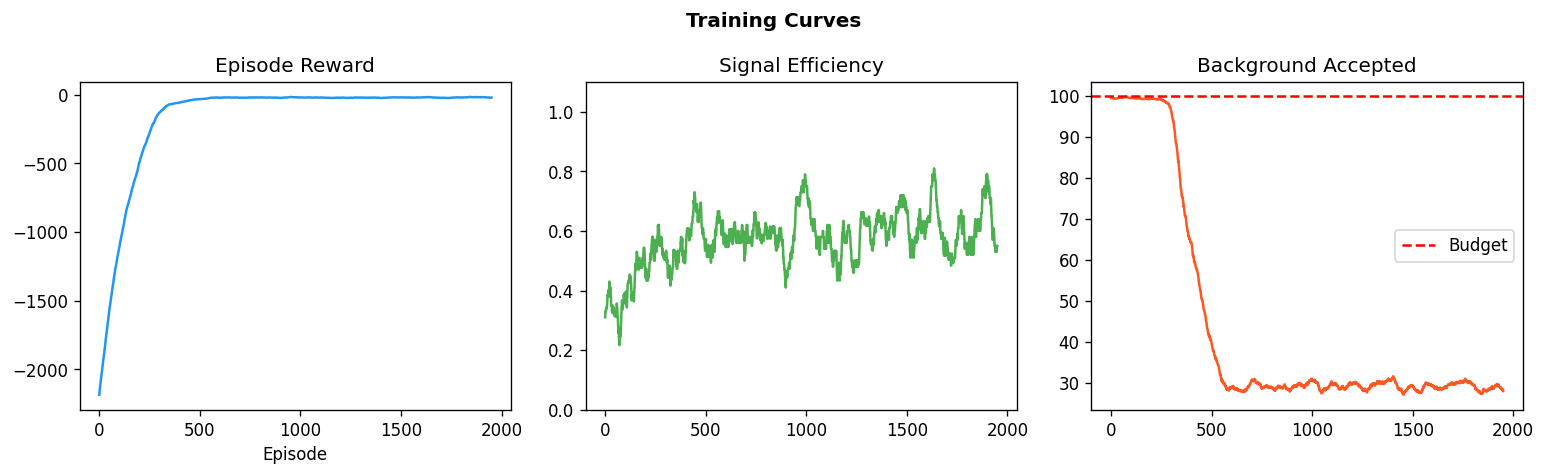

Saved: results/training_curves.png


In [6]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 120

def smooth(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode="valid")


# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Training Curves", fontweight="bold")

axes[0].plot(smooth(rewards),  color="#2196F3")
axes[0].set_title("Episode Reward"); axes[0].set_xlabel("Episode")

axes[1].plot(smooth(sig_effs), color="#4CAF50")
axes[1].set_title("Signal Efficiency"); axes[1].set_ylim(0, 1.1)

axes[2].plot(smooth(bkg_accs), color="#FF5722")
axes[2].axhline(STORAGE_BUDGET, color="red", linestyle="--", label="Budget")
axes[2].set_title("Background Accepted"); axes[2].legend()

plt.tight_layout()
plt.savefig("results/training_curves.png")
plt.show()
print("Saved: results/training_curves.png")

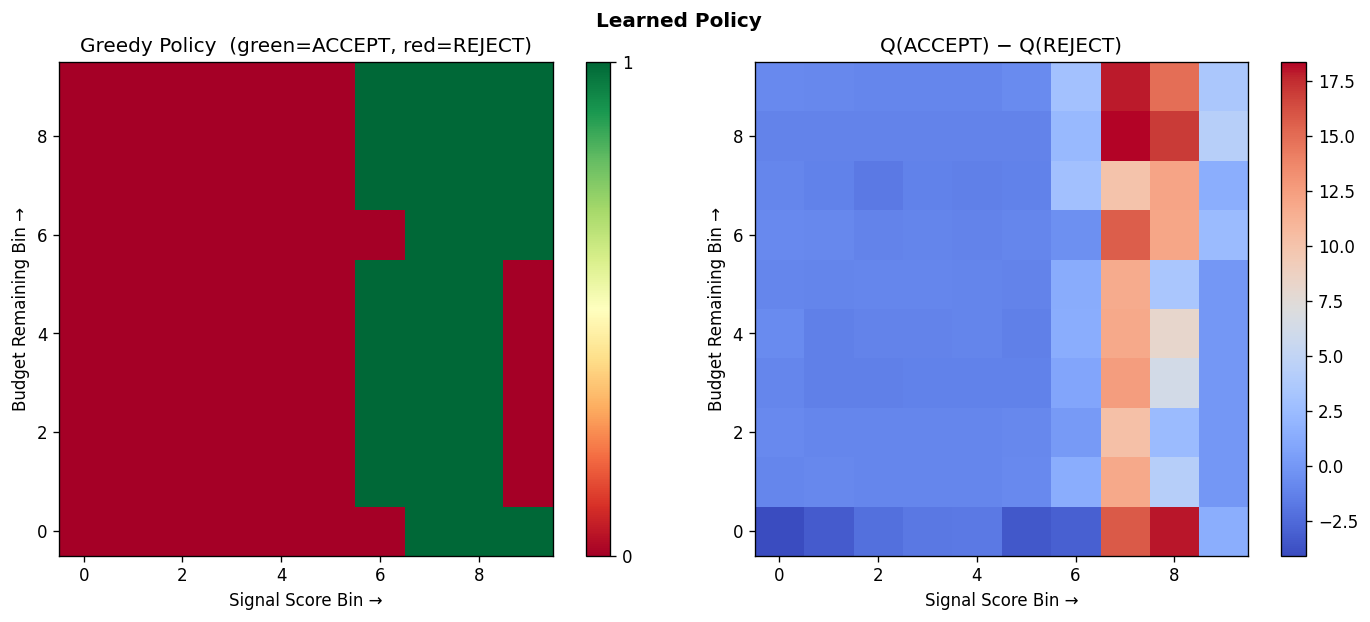

Saved: results/policy_heatmap.png


In [7]:
# ── Policy heatmap ────────────────────────────────────────────────────────────
policy = np.argmax(agent.Q, axis=-1)       # shape (score_bins, budget_bins)
qdiff  = agent.Q[:, :, 1] - agent.Q[:, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Learned Policy", fontweight="bold")

im = axes[0].imshow(policy.T, origin="lower", cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_title("Greedy Policy  (green=ACCEPT, red=REJECT)")
axes[0].set_xlabel("Signal Score Bin →")
axes[0].set_ylabel("Budget Remaining Bin →")
plt.colorbar(im, ax=axes[0], ticks=[0, 1])

im2 = axes[1].imshow(qdiff.T, origin="lower", cmap="coolwarm")
axes[1].set_title("Q(ACCEPT) − Q(REJECT)")
axes[1].set_xlabel("Signal Score Bin →")
axes[1].set_ylabel("Budget Remaining Bin →")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig("results/policy_heatmap.png")
plt.show()
print("Saved: results/policy_heatmap.png")

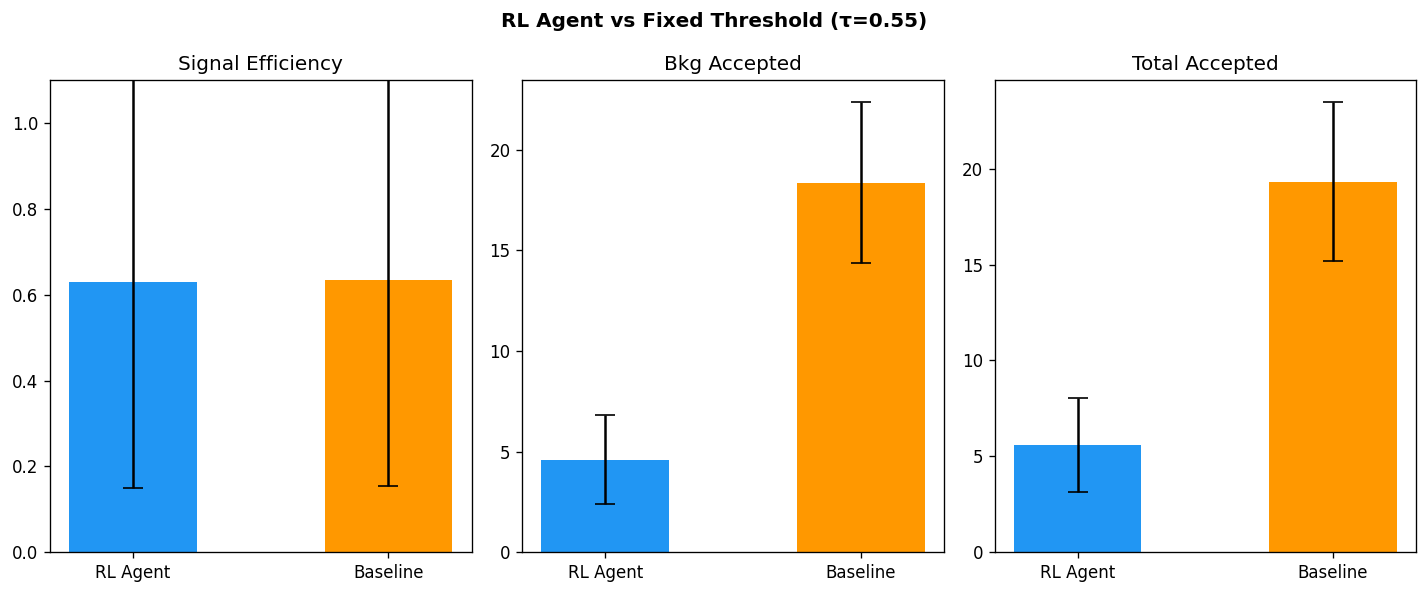

Saved: results/comparison.png


In [8]:
# ── RL Agent vs Baseline comparison ──────────────────────────────────────────
metrics = ["signal_efficiency", "bkg_accepted", "total_accepted"]
labels  = ["Signal Efficiency", "Bkg Accepted", "Total Accepted"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle("RL Agent vs Fixed Threshold (τ=0.55)", fontweight="bold")

for ax, metric, label in zip(axes, metrics, labels):
    rl  = [r[metric] for r in rl_results]
    bl  = [r[metric] for r in bl_results]
    ax.bar(["RL Agent", "Baseline"], [np.mean(rl), np.mean(bl)],
           yerr=[np.std(rl), np.std(bl)],
           color=["#2196F3", "#FF9800"], capsize=6, width=0.5)
    ax.set_title(label)
    if metric == "signal_efficiency":
        ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig("results/comparison.png")
plt.show()
print("Saved: results/comparison.png")

## 7 — Q-table Inspection

Because the Q-function is fully tabular, we can directly read what the agent learned.

In [9]:
print("Q-table summary (Q[ACCEPT] − Q[REJECT] per state):")
print("  Positive → agent prefers to ACCEPT in that state")
print("  Negative → agent prefers to REJECT in that state")
print()

print("Score bin  | Budget bin | Q(accept)-Q(reject) | Decision")
print("-" * 58)
for s in range(N_SCORE_BINS):
    for b in [0, 4, 9]:   # low / mid / high budget
        diff     = agent.Q[s, b, 1] - agent.Q[s, b, 0]
        decision = "ACCEPT" if diff > 0 else "REJECT"
        print(f"  score={s:2d}   budget={b:2d}       {diff:+.3f}            {decision}")

Q-table summary (Q[ACCEPT] − Q[REJECT] per state):
  Positive → agent prefers to ACCEPT in that state
  Negative → agent prefers to REJECT in that state

Score bin  | Budget bin | Q(accept)-Q(reject) | Decision
----------------------------------------------------------
  score= 0   budget= 0       -4.072            REJECT
  score= 0   budget= 4       -0.736            REJECT
  score= 0   budget= 9       -0.797            REJECT
  score= 1   budget= 0       -3.210            REJECT
  score= 1   budget= 4       -1.284            REJECT
  score= 1   budget= 9       -0.845            REJECT
  score= 2   budget= 0       -2.148            REJECT
  score= 2   budget= 4       -1.102            REJECT
  score= 2   budget= 9       -0.985            REJECT
  score= 3   budget= 0       -1.776            REJECT
  score= 3   budget= 4       -1.106            REJECT
  score= 3   budget= 9       -0.927            REJECT
  score= 4   budget= 0       -1.625            REJECT
  score= 4   budget= 4      